# 12 · Partial differential equations: heat penetration and diffusion

**Problem.** The surface of a thick steel block is suddenly raised from 20 °C to 320 °C. How does
heat penetrate, and can we measure the thermal diffusivity $\alpha$ from a thermocouple buried
10 mm below the surface?

The temperature obeys the diffusion equation $\partial T/\partial t = \alpha\,\partial^2 T/\partial x^2$
(identical in form to mass diffusion with $D$). For a semi-infinite solid the exact solution is
$$\frac{T - T_s}{T_0 - T_s} = \operatorname{erf}\!\left(\frac{x}{2\sqrt{\alpha t}}\right).$$

**What you will learn**

- discretise the diffusion equation with explicit and Crank-Nicolson schemes
- explain and demonstrate the stability limit r <= 1/2
- distinguish stability from accuracy
- estimate a material property from measurements (an inverse problem)

**Before you start:** notebooks 03 (tridiagonal systems), 06 (finite differences) and 10 (golden section)  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import pdes, optimize
from scipy.special import erf

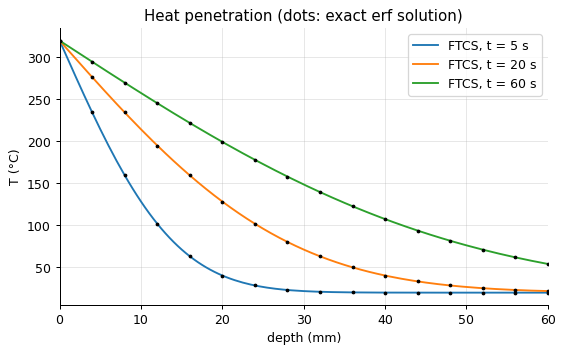

In [2]:
alpha, T0, Ts = 1.2e-5, 20.0, 320.0            # m2/s (typical carbon steel), °C
L, nx = 0.25, 501                               # >= 8 sqrt(alpha t) at 60 s: effectively semi-infinite
x = np.linspace(0, L, nx); dx = x[1] - x[0]
exact = lambda x, t: Ts + (T0 - Ts)*erf(x/(2*np.sqrt(alpha*t)))

fig, ax = plt.subplots()
for t_end in (5, 20, 60):
    dt = 0.4*dx**2/alpha
    T = pdes.ftcs(np.full(nx, T0), alpha, dx, dt, int(round(t_end/dt)), Ts, T0)
    ax.plot(x*1000, T, label=f"FTCS, t = {t_end} s")
    ax.plot(x[::8]*1000, exact(x[::8], t_end), "k.", ms=4)
ax.set(xlim=(0, 60), xlabel="depth (mm)", ylabel="T (°C)", title="Heat penetration (dots: exact erf solution)")
ax.legend(); plt.show()

## Inside the algorithm: the explicit (FTCS) scheme
Replace $\partial T/\partial t$ by a forward difference and $\partial^2T/\partial x^2$ by a central difference:
$$T_i^{n+1} = T_i^n + r\,(T_{i+1}^n - 2T_i^n + T_{i-1}^n), \qquad r = \frac{\alpha\,\Delta t}{\Delta x^2}.$$
In NumPy the update of all interior nodes is a single line:

In [3]:
def ftcs_by_hand(T, r, steps):
    T = T.copy()
    for _ in range(steps):
        T[1:-1] = T[1:-1] + r * (T[2:] - 2 * T[1:-1] + T[:-2])
    return T

dt = 0.4 * dx**2 / alpha
steps = int(round(20 / dt))
T_start = np.full(nx, T0)
T_start[0] = Ts
diff = np.max(np.abs(ftcs_by_hand(T_start, 0.4, steps) - pdes.ftcs(np.full(nx, T0), alpha, dx, dt, steps, Ts, T0)))
print(f"difference from the library: {diff:.1e} K")

difference from the library: 0.0e+00 K


**Why $r \le 1/2$?** Rewrite the update as $T_i^{n+1} = r\,T_{i-1}^n + (1 - 2r)\,T_i^n + r\,T_{i+1}^n$. For
$r \le 1/2$ all three weights are non-negative and sum to 1, so each new temperature is a weighted
*average* of old ones and can never overshoot. For $r > 1/2$ the middle weight is negative - and a
growing sawtooth appears, as the next section shows.

## Stability of the explicit scheme
FTCS updates each node from its neighbours. It is stable only if $r = \alpha\Delta t/\Delta x^2 \le 1/2$.
Beyond that, errors grow exponentially. (`pdes.ftcs` refuses unstable steps, so the unstable run is
coded by hand here.)

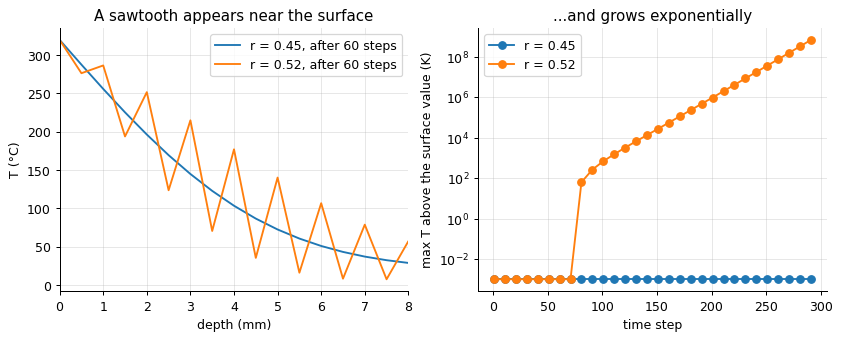

In [4]:
def ftcs_unchecked(T, r, steps):
    T = T.copy()
    for _ in range(steps):
        T[1:-1] = T[1:-1] + r*(T[2:] - 2*T[1:-1] + T[:-2])
    return T

T_init = np.full(nx, T0); T_init[0] = Ts
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for r, col in ((0.45, "C0"), (0.52, "C1")):
    a1.plot(x*1000, ftcs_unchecked(T_init, r, 60), color=col, label=f"r = {r}, after 60 steps")
    overshoot = [np.max(ftcs_unchecked(T_init, r, k)) - Ts for k in range(1, 301, 10)]
    a2.semilogy(range(1, 301, 10), np.maximum(overshoot, 1e-3), "o-", color=col, label=f"r = {r}")
a1.set(xlim=(0, 8), xlabel="depth (mm)", ylabel="T (°C)", title="A sawtooth appears near the surface")
a2.set(xlabel="time step", ylabel="max T above the surface value (K)", title="...and grows exponentially")
a1.legend(); a2.legend(); plt.show()

## Crank-Nicolson: stable with large steps
Averaging the explicit and implicit Laplacians gives a scheme that is unconditionally stable and
second order in time; each step solves one tridiagonal system (Thomas algorithm, notebook 03).

In [5]:
for t_end in (1.0, 60.0):
    for r in (0.4, 10.0, 100.0):
        n = max(1, int(round(t_end/(r*dx**2/alpha))))
        T_cn = pdes.crank_nicolson(np.full(nx, T0), alpha, dx, t_end/n, n, Ts, T0)
        print(f"t = {t_end:4.0f} s, r = {r:5.1f}: {n:5d} steps, max error {np.max(np.abs(T_cn - exact(x, t_end))):8.3f} K")

t =    1 s, r =   0.4:   120 steps, max error    0.084 K
t =    1 s, r =  10.0:     5 steps, max error   42.835 K
t =    1 s, r = 100.0:     1 steps, max error  213.777 K


t =   60 s, r =   0.4:  7200 steps, max error    0.001 K
t =   60 s, r =  10.0:   288 steps, max error    0.001 K
t =   60 s, r = 100.0:    29 steps, max error   74.729 K


Every run is stable - nothing explodes - but **stability is not accuracy**. The sudden surface jump
excites short-wavelength components that Crank-Nicolson damps only weakly when $r$ is large; they
appear as oscillations near the surface, large at early times and still visible after 60 s for
$r = 100$. Small steps at the start (or a few implicit Euler steps first) cure this.

## Inverse problem: measuring the diffusivity
A thermocouple 10 mm deep records the temperature; its readings are in `thermocouple_10mm.csv`
(synthetic, with 1 K noise). Find the $\alpha$ that best fits,
by minimising the sum of squared residuals over $\log_{10}\alpha$ with golden-section search.

alpha = 11.97 ± 0.05 mm²/s  (true 12.0 mm²/s)


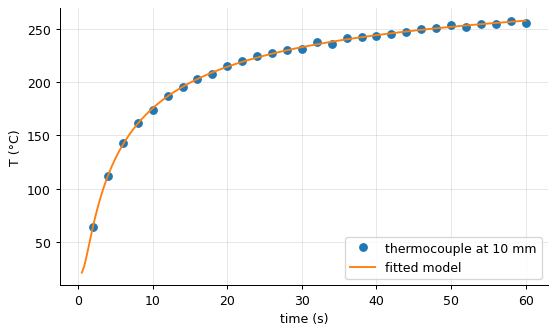

In [6]:
from engmath import datasets
x_tc = 0.010
tc = np.loadtxt(datasets.path("thermocouple_10mm.csv"), delimiter=",", skiprows=1)
t_meas, T_meas = tc[:, 0], tc[:, 1]

def rss(log_a):
    a = 10**log_a
    return np.sum((Ts + (T0 - Ts)*erf(x_tc/(2*np.sqrt(a*t_meas))) - T_meas)**2)

res = optimize.golden_section(rss, -6, -4)
a_fit = 10**res.x[0]
# approximate standard error from the curvature of the RSS (Gauss-Newton)
h = 1e-3*a_fit
Jcol = (erf(x_tc/(2*np.sqrt((a_fit+h)*t_meas))) - erf(x_tc/(2*np.sqrt((a_fit-h)*t_meas))))*(T0 - Ts)/(2*h)
s = np.sqrt(res.fun/(t_meas.size - 1))
se = s/np.sqrt(Jcol @ Jcol)
from engmath.reporting import format_uncertainty
print(f"alpha = {format_uncertainty(a_fit*1e6, se*1e6)} mm²/s  (true {alpha*1e6} mm²/s)")
plt.plot(t_meas, T_meas, "o", label="thermocouple at 10 mm")
tt = np.linspace(0.5, 60, 200)
plt.plot(tt, Ts + (T0 - Ts)*erf(x_tc/(2*np.sqrt(a_fit*tt))), label="fitted model")
plt.xlabel("time (s)"); plt.ylabel("T (°C)"); plt.legend(); plt.show()

## Exercises
1. Repeat the inverse problem with the thermocouple position uncertain by ±0.5 mm. How does that
   uncertainty propagate into $\alpha$? (Hint: $\alpha$ enters only through $x/\sqrt{\alpha t}$.)
2. Replace the fixed surface temperature by convection (a Robin boundary condition) in the
   Crank-Nicolson scheme: which entries of the tridiagonal system change?
3. For mass transfer into a polymer film, the uptake per unit area is
   $M_t = 2C_s\sqrt{Dt/\pi}$ at early times. Show that fitting $M_t$ against $\sqrt t$ is a *linear*
   regression, and use it to estimate $D$ from simulated data with 3 % noise.
4. **Implement it yourself:** implicit (backward) Euler for the heat equation solves $(1 + 2r)T_i^{n+1} - rT_{i-1}^{n+1} - rT_{i+1}^{n+1} = T_i^n$ - one Thomas solve per step. Show that it is stable at $r = 100$ and compare its early-time error with Crank-Nicolson.